# Freight Rate Prediction



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110
TEAL = "#064A56"

DATA = "data"


## 1. Loading data

In [2]:
train_test = pd.read_csv(f"{DATA}/train_test.csv")
validation = pd.read_csv(f"{DATA}/validation.csv")
template = pd.read_csv(f"{DATA}/validation_predictions_template.csv")
december = pd.read_csv(f"{DATA}/december_chart_inputs.csv")

print(train_test.shape, validation.shape, template.shape, december.shape)
train_test.head()

(48000, 14) (12000, 13) (12000, 2) (31, 7)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [3]:
train_test.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
load_id,48000,48000,TR-047984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup,48000,64,Oklahoma City,1242,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery,48000,64,Lexington,1197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_lat,48000.0,NaN,NaN,NaN,35.647545,4.315285,28.35765,31.98691,35.29479,39.41104,44.30296
pickup_lon,48000.0,NaN,NaN,NaN,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.28506,-69.5
delivery_lat,48000.0,NaN,NaN,NaN,35.641175,4.317199,28.35765,31.98691,35.29479,39.41104,44.30296
delivery_lon,48000.0,NaN,NaN,NaN,-90.85731,13.476589,-121.69849,-98.40059,-87.52871,-83.28506,-69.5
distance,48000.0,NaN,NaN,NaN,1135.856654,728.564416,70.0,550.4,953.3,1645.525,3439.8
equipment,48000,3,Dry Van,27202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,47700.0,NaN,NaN,NaN,31028.844004,9391.44062,-47500.0,25800.0,31436.5,37018.0,47500.0


##2. Data quality checks

In [4]:
print("Missing values, train_test.csv:")
print(train_test.isna().sum()[train_test.isna().sum() > 0])
print()
print("Missing values, validation.csv:")
print(validation.isna().sum()[validation.isna().sum() > 0])
print()
print("Date ranges — train_test:", train_test.date.min(), "to", train_test.date.max())
print("Date ranges — validation:", validation.date.min(), "to", validation.date.max())
print("Equipment types:", train_test.equipment.unique())
print("Unique lanes:", train_test.pickup.nunique(), "pickups x", train_test.delivery.nunique(), "deliveries")

Missing values, train_test.csv:
weight          300
market_index    374
dtype: int64

Missing values, validation.csv:
weight          165
market_index    249
dtype: int64

Date ranges — train_test: 2025-01-01 to 2025-10-31
Date ranges — validation: 2025-11-01 to 2025-12-31
Equipment types: ['Dry Van' 'Reefer' 'Flatbed']
Unique lanes: 64 pickups x 64 deliveries


In [5]:
neg_weight = (train_test.weight < 0).sum()
print(f"Negative weight rows: {neg_weight} ({neg_weight/len(train_test):.2%})")
print(train_test.loc[train_test.weight < 0, "weight"].describe())

Negative weight rows: 292 (0.61%)
count      292.000000
mean    -31724.195205
std       8262.536326
min     -47500.000000
25%     -37284.250000
50%     -31821.500000
75%     -25928.500000
max      -5000.000000
Name: weight, dtype: float64


In [20]:
from math import radians

def haversine_miles(row):
    lat1, lon1, lat2, lon2 = map(radians, [row.pickup_lat, row.pickup_lon, row.delivery_lat, row.delivery_lon])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 3958.8 * 2 * np.arcsin(np.sqrt(a))

sample = train_test.sample(3000, random_state=0).copy()
sample["haversine"] = sample.apply(haversine_miles, axis=1)
diff = (sample["haversine"] - sample["distance"]).abs()
print("Mean |distance - haversine| (mi):", round(diff.mean(), 1), " max:", round(diff.max(), 1))
print("-> distance column kept as-is; lat/lon not used as model features.")

Mean |distance - haversine| (mi): 170.7  max: 514.3
-> distance column kept as-is; lat/lon not used as model features.


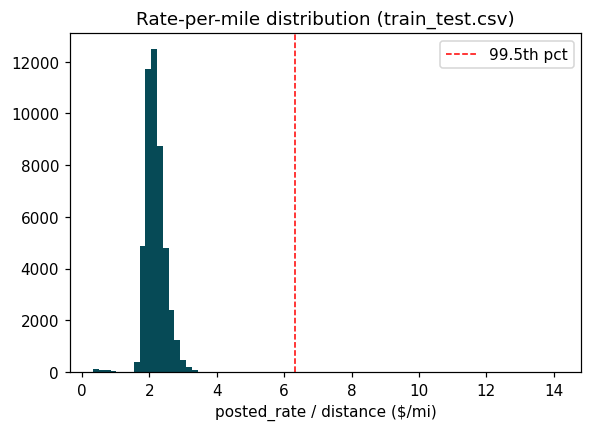

Rows with rpm > 5 $/mi: 317 (0.66%)


In [7]:
tt = train_test.copy()
tt["rpm"] = tt.posted_rate / tt.distance
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(tt.rpm, bins=80, color=TEAL)
ax.axvline(tt.rpm.quantile(0.995), color="red", linestyle="--", linewidth=1, label="99.5th pct")
ax.set_xlabel("posted_rate / distance ($/mi)")
ax.set_title("Rate-per-mile distribution (train_test.csv)")
ax.legend()
plt.show()
print(f"Rows with rpm > 5 $/mi: {(tt.rpm > 5).sum()} ({(tt.rpm > 5).mean():.2%})")

## 3. Estimating market_index/ quote_signal for the December fixed lane



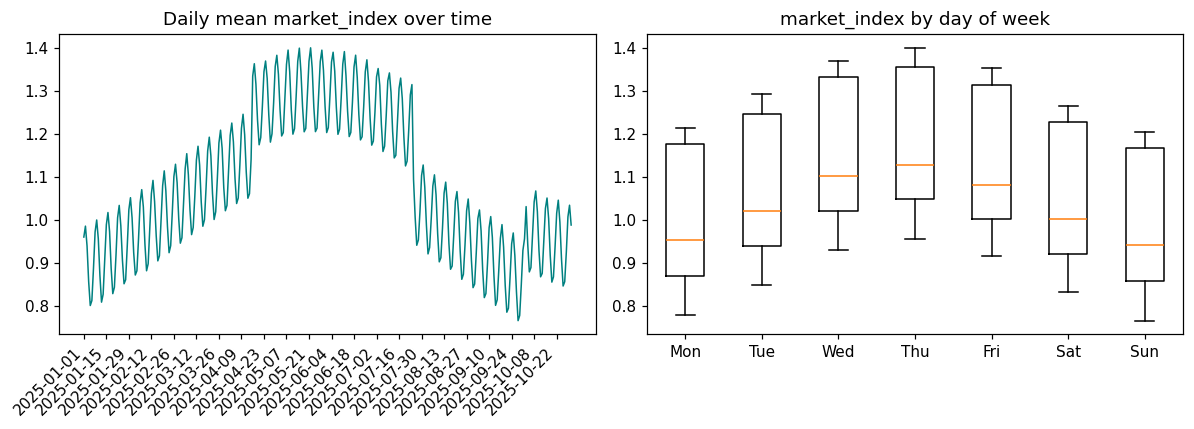

In [24]:
daily = train_test.groupby("date")[["market_index", "quote_signal"]].mean().reset_index()
daily["date"] = pd.to_datetime(daily["date"])
daily["dow"] = daily["date"].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(daily["date"], daily["market_index"], color="teal", linewidth=1)
axes[0].set_title("Daily mean market_index over time")

# --- fix: show every Nth label, angled, instead of every single date ---
tick_step = 14  # show a label every 14 days — adjust to taste
axes[0].set_xticks(daily["date"][::tick_step])
axes[0].set_xticklabels(daily["date"].dt.strftime("%Y-%m-%d")[::tick_step],
                         rotation=45, ha="right")

axes[1].boxplot([daily.loc[daily.dow == d, "market_index"] for d in range(7)],
                tick_labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[1].set_title("market_index by day of week")

plt.tight_layout()
plt.show()

In [9]:
def build_daily_market_reference(*frames):
    """Stack every frame that has observed market_index/quote_signal and average by date."""
    parts = [f[["date", "market_index", "quote_signal"]] for f in frames if "market_index" in f.columns]
    stacked = pd.concat(parts, ignore_index=True)
    return stacked.groupby("date")[["market_index", "quote_signal"]].mean()


def estimate_missing_market_signal(daily_ref):
    """Fallback day-of-week + smooth annual-seasonality regression, only used if a date
    has zero observed rows anywhere (keeps the pipeline robust to edge cases)."""
    ref = daily_ref.reset_index().copy()
    ref["date"] = pd.to_datetime(ref["date"])
    ref["doy"] = ref["date"].dt.dayofyear
    ref["dow"] = ref["date"].dt.dayofweek
    X = pd.get_dummies(ref["dow"], prefix="dow", drop_first=True)
    X["sin1"] = np.sin(2 * np.pi * ref["doy"] / 365.25)
    X["cos1"] = np.cos(2 * np.pi * ref["doy"] / 365.25)
    X["t"] = (ref["date"] - ref["date"].min()).dt.days
    models = {col: LinearRegression().fit(X, ref[col]) for col in ["market_index", "quote_signal"]}
    return models, X.columns.tolist(), ref["date"].min()

## 4. Feature engineering

In [10]:
CATEGORICAL_COLS = ["pickup", "delivery", "equipment"]
NUMERIC_COLS = ["distance", "weight", "market_index", "quote_signal",
                 "month", "day_of_week", "day_of_year", "is_weekend"]
ALL_FEATURE_COLS = CATEGORICAL_COLS + NUMERIC_COLS


def clean_weight(series):
    return series.abs()


def add_date_features(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek
    df["day_of_year"] = df["date"].dt.dayofyear
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df


def prepare_features(df, daily_ref, fallback_models=None, fallback_cols=None, fallback_min_date=None):
    df = add_date_features(df)
    df["weight"] = clean_weight(df["weight"])
    df["weight"] = df["weight"].fillna(df.groupby("equipment")["weight"].transform("median"))

    ref = daily_ref.copy()
    ref.index = pd.to_datetime(ref.index)
    for col in ["market_index", "quote_signal"]:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = df[col].fillna(df["date"].map(ref[col]))

    still_missing = df["market_index"].isna() | df["quote_signal"].isna()
    if still_missing.any() and fallback_models is not None:
        sub = df.loc[still_missing, "date"]
        doy, dow = sub.dt.dayofyear, sub.dt.dayofweek
        Xf = pd.get_dummies(dow, prefix="dow", drop_first=True)
        Xf["sin1"] = np.sin(2 * np.pi * doy / 365.25)
        Xf["cos1"] = np.cos(2 * np.pi * doy / 365.25)
        Xf["t"] = (sub - fallback_min_date).dt.days
        Xf = Xf.reindex(columns=fallback_cols, fill_value=0)
        for col in ["market_index", "quote_signal"]:
            pred = fallback_models[col].predict(Xf)
            df.loc[still_missing, col] = df.loc[still_missing, col].fillna(pd.Series(pred, index=sub.index))

    for col in CATEGORICAL_COLS:
        df[col] = df[col].astype("category")
    return df[ALL_FEATURE_COLS]

## 5. Train / validation split

In [11]:
daily_ref_tt = build_daily_market_reference(train_test)
fb_models_tt, fb_cols_tt, fb_min_tt = estimate_missing_market_signal(daily_ref_tt)

X_all = prepare_features(train_test, daily_ref_tt, fb_models_tt, fb_cols_tt, fb_min_tt)
y_all = train_test["posted_rate"].astype(float)
dates = pd.to_datetime(train_test["date"])

cutoff = pd.Timestamp("2025-09-01")
train_mask = dates < cutoff
holdout_mask = ~train_mask
print(f"Train: {train_mask.sum():,} rows (Jan-Aug) | Holdout: {holdout_mask.sum():,} rows (Sep-Oct)")

Train: 38,477 rows (Jan-Aug) | Holdout: 9,523 rows (Sep-Oct)


## 6. Model


In [12]:
cat_idx = [ALL_FEATURE_COLS.index(c) for c in CATEGORICAL_COLS]

def make_model():
    return HistGradientBoostingRegressor(
        loss="absolute_error", max_depth=8, learning_rate=0.06, max_iter=500,
        l2_regularization=0.1, categorical_features=cat_idx,
        early_stopping=True, validation_fraction=0.1, random_state=42,
    )

model = make_model().fit(X_all[train_mask], y_all[train_mask])
pred_holdout = model.predict(X_all[holdout_mask])
y_holdout = y_all[holdout_mask]


Time-based holdout (Sep-Oct 2025):
  MAE: 110.2647
  RMSE: 635.1819
  MAPE: 0.0475
  R2: 0.8268


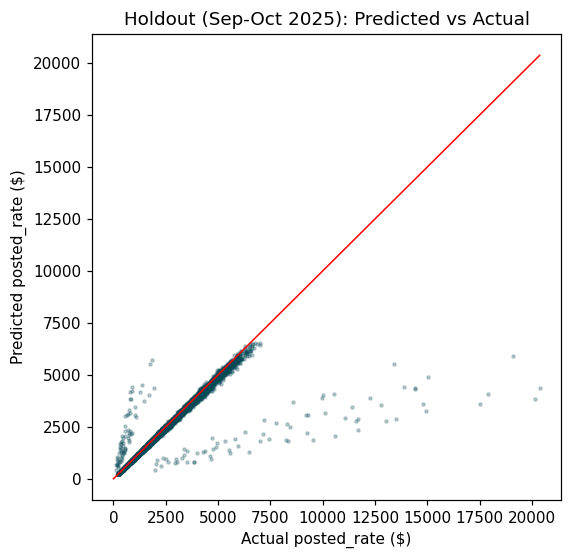

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_holdout, pred_holdout, s=4, alpha=0.25, color=TEAL)
lims = [0, max(y_holdout.max(), pred_holdout.max())]
ax.plot(lims, lims, color="red", linewidth=1)
ax.set_xlabel("Actual posted_rate ($)")
ax.set_ylabel("Predicted posted_rate ($)")
ax.set_title("Holdout (Sep-Oct 2025): Predicted vs Actual")
plt.show()

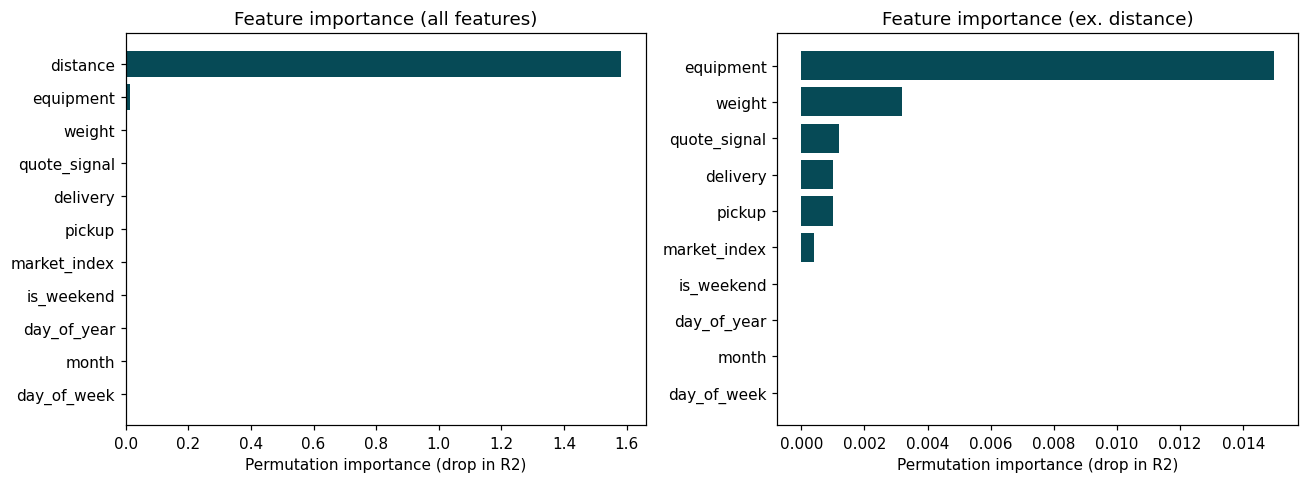

In [15]:
perm = permutation_importance(model, X_all[holdout_mask], y_holdout, n_repeats=5, random_state=42, n_jobs=-1)
order = np.argsort(perm.importances_mean)
cols = np.array(ALL_FEATURE_COLS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(cols[order], perm.importances_mean[order], color=TEAL)
axes[0].set_title("Feature importance (all features)")
axes[0].set_xlabel("Permutation importance (drop in R2)")

keep = cols[order] != "distance"
axes[1].barh(cols[order][keep], perm.importances_mean[order][keep], color=TEAL)
axes[1].set_title("Feature importance (ex. distance)")
axes[1].set_xlabel("Permutation importance (drop in R2)")
plt.tight_layout()
plt.show()

## 7. Refit on all labeled data

In [16]:
final_model = HistGradientBoostingRegressor(
    loss="absolute_error", max_depth=8, learning_rate=0.06, max_iter=model.n_iter_,
    l2_regularization=0.1, categorical_features=cat_idx, random_state=42,
).fit(X_all, y_all)
print(f"Refit on {len(X_all):,} rows using {model.n_iter_} boosting iterations.")

Refit on 48,000 rows using 500 boosting iterations.


## 8. Validation predictions

In [17]:
daily_ref_full = build_daily_market_reference(train_test, validation)
fb_models_full, fb_cols_full, fb_min_full = estimate_missing_market_signal(daily_ref_full)

X_val = prepare_features(validation, daily_ref_full, fb_models_full, fb_cols_full, fb_min_full)
validation = validation.copy()
validation["predicted_rate"] = final_model.predict(X_val)

preds = template[["load_id"]].merge(validation[["load_id", "predicted_rate"]], on="load_id", how="left")
assert preds["predicted_rate"].isna().sum() == 0
preds.to_csv("validation_predictions.csv", index=False)
print(f"Wrote {len(preds):,} rows to validation_predictions.csv")
preds.head()

Wrote 12,000 rows to validation_predictions.csv


,load_id,predicted_rate
0,TE-000001,843.907744
1,TE-000002,5145.201410
2,TE-000003,5318.726864
3,TE-000004,4140.599549
4,TE-000005,1782.468342


## 9. Predict the December fixed-lane chart inputs

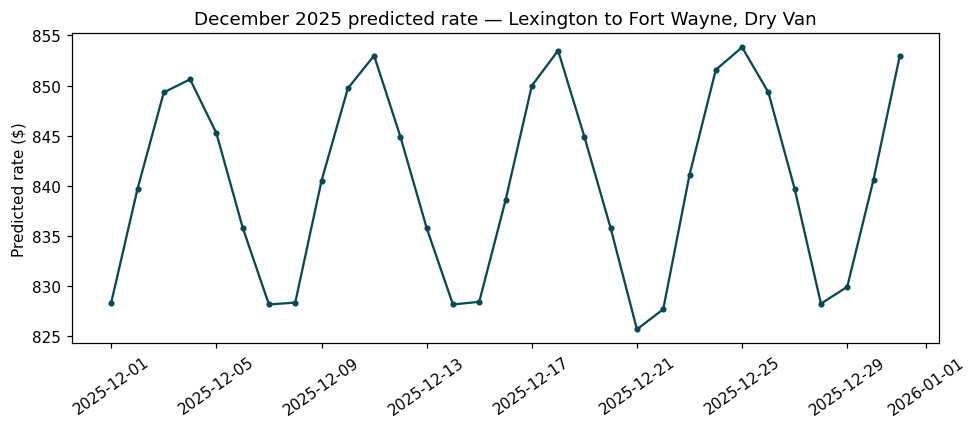

,date,predicted_rate
0,2025-12-01,828.349747
1,2025-12-02,839.693469
2,2025-12-03,849.317586
3,2025-12-04,850.623543
4,2025-12-05,845.256766
5,2025-12-06,835.835076
6,2025-12-07,828.162297
7,2025-12-08,828.349747
8,2025-12-09,840.497238
9,2025-12-10,849.709057


In [18]:
december = december.copy()
X_dec = prepare_features(december.drop(columns=["predicted_rate"]), daily_ref_full,
                          fb_models_full, fb_cols_full, fb_min_full)
december["predicted_rate"] = final_model.predict(X_dec)
december.to_csv("december_chart_inputs_filled.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4))
d = december.copy()
d["date"] = pd.to_datetime(d["date"])
ax.plot(d["date"], d["predicted_rate"], marker="o", markersize=3, color=TEAL)
ax.set_title("December 2025 predicted rate — Lexington to Fort Wayne, Dry Van")
ax.set_ylabel("Predicted rate ($)")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()
december[["date", "predicted_rate"]]

## 10. Validate outputs with the provided scorer


In [21]:
!python score.py --predictions validation_predictions.csv \
                  --december-predictions december_chart_inputs_filled.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


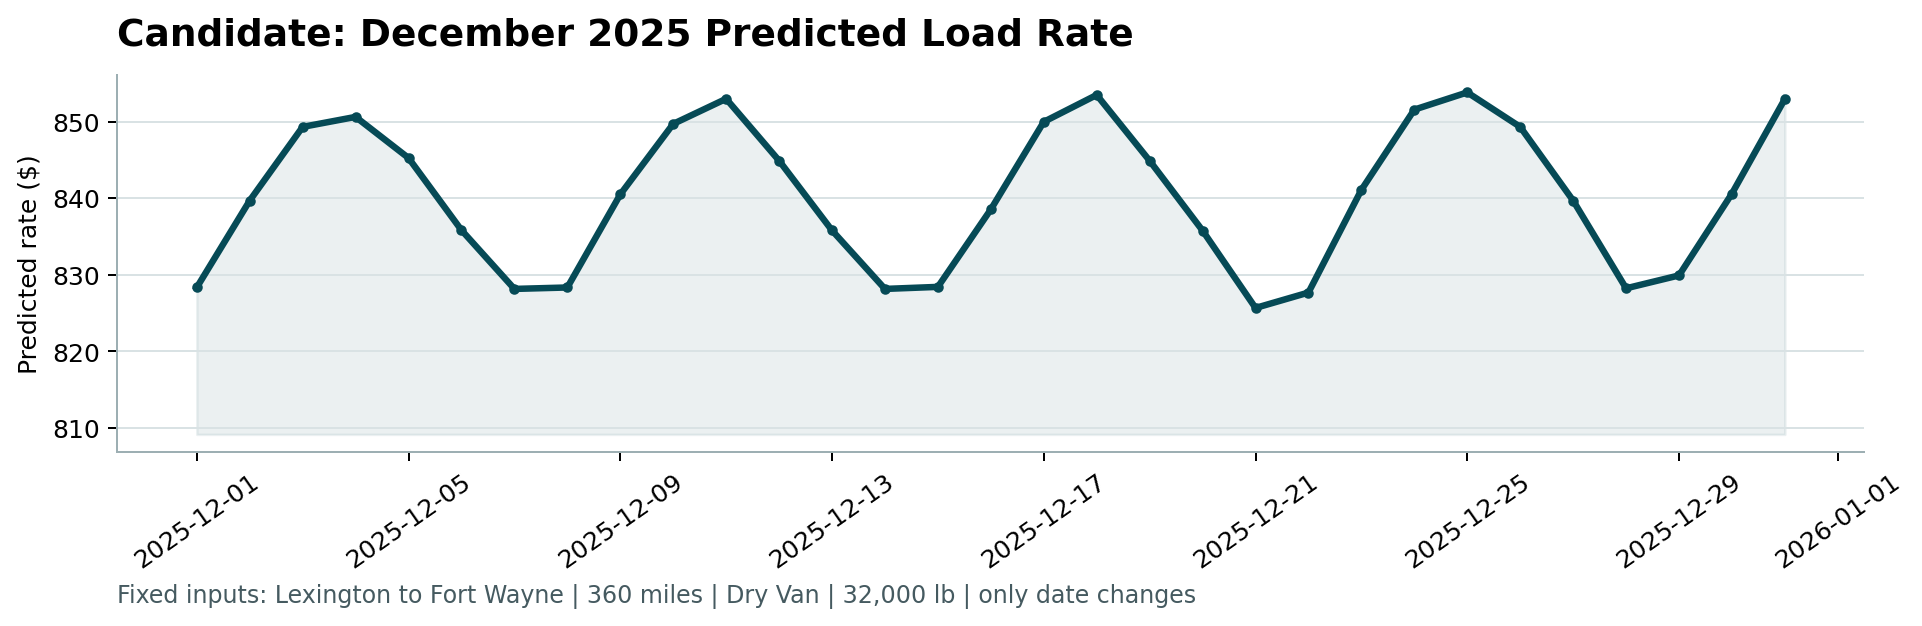

In [22]:
from IPython.display import Image
Image("scorer_results/candidate_december.png")